# Qual é o melhor plano?

Você trabalha como analista para a empresa de telecomunicações Megaline. A empresa oferece aos clientes dois planos pré-pagos: Surf e Ultimate. O departamento comercial quer saber qual dos planos gera mais receita para ajustar o orçamento de publicidade.

Você vai realizar uma análise preliminar dos planos com base em uma pequena seleção de clientes. Você terá dados de 500 clientes da Megaline: que clientes são, de onde eles são, qual plano usam e o número de chamadas e mensagens realizadas em 2018. Seu trabalho é analisar o comportamento dos clientes e determinar qual plano pré-pago gera mais receita.

###### Fornecemos alguns comentários para guiar sua linha de raciocínio enquanto você trabalha neste projeto. Entretanto, certifique-se de remover todos os comentários entre colchetes antes de enviar o projeto.

###### Antes de começar a análise dos dados, explique com suas próprias palavras o propósito do projeto e as ações que planeja realizar.

###### Tenha em mente que estudar, modificar e analisar dados é um processo iterativo. É normal retornar a etapas anteriores e corrigir/expandir algo para permitir as próximas etapas.

## Inicialização

In [17]:
# Carregando todas as bibliotecas
import pandas as pd           
import numpy as np              
import matplotlib.pyplot as plt 
import seaborn as sns           
import scipy.stats as st        

## Carregue os dados

In [18]:
# Carregue os arquivos de dados em diferentes DataFrames
calls = pd.read_csv('/datasets/megaline_calls.csv')
internet = pd.read_csv('/datasets/megaline_internet.csv')
messages = pd.read_csv('/datasets/megaline_messages.csv')
plans = pd.read_csv('/datasets/megaline_plans.csv')
users = pd.read_csv('/datasets/megaline_users.csv')

## Prepare os dados

##### Os dados deste projeto estão divididos em várias tabelas. Explore cada uma para obter uma compreensão inicial dos dados. Faça correções em cada tabela, se necessário.

## Planos

In [19]:
# Imprima informações gerais/resumo sobre o DataFrame dos planos
print(calls.head())
print(internet.head())
print(messages.head())
print(plans.head())
print(users.head())


         id  user_id   call_date  duration
0   1000_93     1000  2018-12-27      8.52
1  1000_145     1000  2018-12-27     13.66
2  1000_247     1000  2018-12-27     14.48
3  1000_309     1000  2018-12-28      5.76
4  1000_380     1000  2018-12-30      4.22
         id  user_id session_date  mb_used
0   1000_13     1000   2018-12-29    89.86
1  1000_204     1000   2018-12-31     0.00
2  1000_379     1000   2018-12-28   660.40
3  1000_413     1000   2018-12-26   270.99
4  1000_442     1000   2018-12-27   880.22
         id  user_id message_date
0  1000_125     1000   2018-12-27
1  1000_160     1000   2018-12-31
2  1000_223     1000   2018-12-31
3  1000_251     1000   2018-12-27
4  1000_255     1000   2018-12-26
   messages_included  mb_per_month_included  minutes_included  \
0                 50                  15360               500   
1               1000                  30720              3000   

   usd_monthly_pay  usd_per_gb  usd_per_message  usd_per_minute plan_name  
0       

In [4]:
# Imprima uma amostra de dados dos planos

print(calls.info())
print(internet.info())
print(messages.info())
print(plans.info())
print(users.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 137735 entries, 0 to 137734
Data columns (total 4 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   id         137735 non-null  object 
 1   user_id    137735 non-null  int64  
 2   call_date  137735 non-null  object 
 3   duration   137735 non-null  float64
dtypes: float64(1), int64(1), object(2)
memory usage: 4.2+ MB
None
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 104825 entries, 0 to 104824
Data columns (total 4 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   id            104825 non-null  object 
 1   user_id       104825 non-null  int64  
 2   session_date  104825 non-null  object 
 3   mb_used       104825 non-null  float64
dtypes: float64(1), int64(1), object(2)
memory usage: 3.2+ MB
None
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 76051 entries, 0 to 76050
Data columns (total 3 columns):
 #   Column        Non-Null 

##### Descreva o que você nota sobre as informações gerais e sobre a amostra de dados impressa acima. Existem problemas (tipos de dados inadequados, dados ausentes, etc.) que precisam de mais investigação e alterações? Como isso pode ser corrigido?
Minhas observacoes foram:
Conversao de colunas de data para o tipo datetime;
Arredondamento da duração das chamadas (duration);
Conversao do uso de dados de MB para GB;
Tratar os valores ausentes;

## Corrija os dados

##### Corrija problemas óbvios com os dados conforme as observações iniciais.
'Users': A coluna reg_date foi convertida para datetime, e a coluna churn_date tem valores ausentes (NaT), o que é normal em dados de clientes que não cancelaram o serviço.

In [20]:
import pandas as pd

# Corrigindo os tipos de dados na tabela users
users['reg_date'] = pd.to_datetime(users['reg_date'])
users['churn_date'] = pd.to_datetime(users['churn_date'], errors='coerce')

# Preenchendo valores ausentes em churn_date com NaT (normal para clientes ativos)
users['churn_date'].fillna(pd.NaT, inplace=True)

print(users.head())

   user_id first_name  last_name  age                                   city  \
0     1000   Anamaria      Bauer   45  Atlanta-Sandy Springs-Roswell, GA MSA   
1     1001     Mickey  Wilkerson   28        Seattle-Tacoma-Bellevue, WA MSA   
2     1002     Carlee    Hoffman   36   Las Vegas-Henderson-Paradise, NV MSA   
3     1003   Reynaldo    Jenkins   52                          Tulsa, OK MSA   
4     1004    Leonila   Thompson   40        Seattle-Tacoma-Bellevue, WA MSA   

    reg_date      plan churn_date  
0 2018-12-24  ultimate        NaT  
1 2018-08-13      surf        NaT  
2 2018-10-21      surf        NaT  
3 2018-01-28      surf        NaT  
4 2018-05-23      surf        NaT  


## Enriqueça os dados

##### Inclua fatores adicionais aos dados se você acredita que eles podem ser úteis.
Poderiamos incluir:
Calcular a receita mensal por usuario, o total de chamadas e msgs, consumo total de dados, criar novas variaveis temporais por ex: Mes e ano de registro e categogorizar os usuarios pelo tipo de plano.



In [21]:
# Dicionário com valores de mensalidade por plano
plan_monthly_revenue = {
    'surf': 20,
    'ultimate': 70
}

# Criar a coluna de receita mensal com base no plano
users['monthly_revenue'] = users['plan'].map(plan_monthly_revenue)

print(users[['user_id', 'plan', 'monthly_revenue']].head())

   user_id      plan  monthly_revenue
0     1000  ultimate               70
1     1001      surf               20
2     1002      surf               20
3     1003      surf               20
4     1004      surf               20


In [7]:
# Calcular a receita mensal por usuário (agora que temos a coluna 'monthly_revenue')
calls = calls.merge(users[['user_id', 'monthly_revenue']], on='user_id', how='left')

# Calcular o total de chamadas por usuário (soma da duração das chamadas)
total_calls = calls.groupby('user_id')['duration'].sum().reset_index()
total_calls.rename(columns={'duration': 'total_duration'}, inplace=True)

# Calcular o total de mensagens enviadas por usuário (contagem de mensagens)
total_messages = messages.groupby('user_id').size().reset_index(name='total_messages')

# Calcular o total de dados consumidos por usuário (soma do uso de dados)
total_data = internet.groupby('user_id')['mb_used'].sum().reset_index()
total_data.rename(columns={'mb_used': 'total_data_gb'}, inplace=True)

# Criando variáveis adicionais de data
users['registration_month'] = users['reg_date'].dt.month
users['registration_year'] = users['reg_date'].dt.year

# Juntando as informações
users_final = users.merge(total_calls, on='user_id', how='left')
users_final = users_final.merge(total_messages, on='user_id', how='left')
users_final = users_final.merge(total_data, on='user_id', how='left')

print(users_final.head())

   user_id first_name  last_name  age                                   city  \
0     1000   Anamaria      Bauer   45  Atlanta-Sandy Springs-Roswell, GA MSA   
1     1001     Mickey  Wilkerson   28        Seattle-Tacoma-Bellevue, WA MSA   
2     1002     Carlee    Hoffman   36   Las Vegas-Henderson-Paradise, NV MSA   
3     1003   Reynaldo    Jenkins   52                          Tulsa, OK MSA   
4     1004    Leonila   Thompson   40        Seattle-Tacoma-Bellevue, WA MSA   

    reg_date      plan churn_date  monthly_revenue  registration_month  \
0 2018-12-24  ultimate        NaT               70                  12   
1 2018-08-13      surf        NaT               20                   8   
2 2018-10-21      surf        NaT               20                  10   
3 2018-01-28      surf        NaT               20                   1   
4 2018-05-23      surf        NaT               20                   5   

   registration_year  total_duration  total_messages  total_data_gb  
0   

## Usuários

In [22]:
# Imprima informações gerais/resumo sobre o DataFrame dos usuários
print(users.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 9 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   user_id          500 non-null    int64         
 1   first_name       500 non-null    object        
 2   last_name        500 non-null    object        
 3   age              500 non-null    int64         
 4   city             500 non-null    object        
 5   reg_date         500 non-null    datetime64[ns]
 6   plan             500 non-null    object        
 7   churn_date       34 non-null     datetime64[ns]
 8   monthly_revenue  500 non-null    int64         
dtypes: datetime64[ns](2), int64(3), object(4)
memory usage: 35.3+ KB
None


In [23]:
# Imprima uma amostra de dados dos usuários
print(users.head())

   user_id first_name  last_name  age                                   city  \
0     1000   Anamaria      Bauer   45  Atlanta-Sandy Springs-Roswell, GA MSA   
1     1001     Mickey  Wilkerson   28        Seattle-Tacoma-Bellevue, WA MSA   
2     1002     Carlee    Hoffman   36   Las Vegas-Henderson-Paradise, NV MSA   
3     1003   Reynaldo    Jenkins   52                          Tulsa, OK MSA   
4     1004    Leonila   Thompson   40        Seattle-Tacoma-Bellevue, WA MSA   

    reg_date      plan churn_date  monthly_revenue  
0 2018-12-24  ultimate        NaT               70  
1 2018-08-13      surf        NaT               20  
2 2018-10-21      surf        NaT               20  
3 2018-01-28      surf        NaT               20  
4 2018-05-23      surf        NaT               20  


##### Descreva o que você nota sobre as informações gerais e sobre a amostra de dados impressa acima. Existem problemas (tipos de dados inadequados, dados ausentes, etc.) que precisam de mais investigação e alterações? Como isso pode ser corrigido?
Tipos de dados estão corretos.
Churn_date possui valores ausentes (NaT), indicando que a maioria dos usuários ainda está ativa. Considerar ao fazer análises futuras.
Nenhuma outra coluna tem valores ausentes.

As variáveis temporais (registration_month, registration_year) foram criadas corretamente e a coluna monthly_revenue foi adicionada com base no plano.



### Corrija os dados

##### Corrija problemas óbvios com os dados conforme as observações iniciais.
A coluna 'churn_date' tem valores ausentes que precisam ser tratados, criei a coluna is_active para indicar se o cliente ainda é ativo, ja que os valores nulos em 'churn_date' representam usuarios que nao cancelaram.

In [24]:
# Corrigir o problema de churn_date ausente
users['is_active'] = users['churn_date'].isna()

# Conferir a correção
print(users[['user_id', 'churn_date', 'is_active']].head())

   user_id churn_date  is_active
0     1000        NaT       True
1     1001        NaT       True
2     1002        NaT       True
3     1003        NaT       True
4     1004        NaT       True


### Enriqueça os dados

##### Inclua fatores adicionais aos dados se você acredita que eles podem ser úteis.
Corrigi a forma de calcular a diferença em meses. O cálculo considera que cada mês tem aproximadamente 30 dias e 'months_as_customer' tempo de relacionamento com a empresa.
Criar uma coluna chamada 'age_group'categorizando os usuarios por idade e region baseada em cidades.

In [25]:
# Calcular o tempo como cliente em meses
from datetime import datetime

# Definir a data atual (01/01/2019)
current_date = pd.to_datetime('2019-01-01')

# Calcular a diferença em meses entre a data de registro e a data atual
users['months_as_customer'] = ((current_date - users['reg_date']).dt.days / 30).astype(int)

# Exibir as primeiras linhas para verificar
print(users
      [['user_id', 'reg_date', 'months_as_customer']].head())

   user_id   reg_date  months_as_customer
0     1000 2018-12-24                   0
1     1001 2018-08-13                   4
2     1002 2018-10-21                   2
3     1003 2018-01-28                  11
4     1004 2018-05-23                   7


In [26]:
# Definir as faixas etárias
def classify_age(age):
    if age <= 30:
        return 'Jovem'
    elif 31 <= age <= 50:
        return 'Adulto'
    else:
        return 'Idoso'

# Aplicar a classificação
users['age_group'] = users['age'].apply(classify_age)

# Verificar os resultados
print(users[['user_id', 'age', 'age_group']].head())

   user_id  age age_group
0     1000   45    Adulto
1     1001   28     Jovem
2     1002   36    Adulto
3     1003   52     Idoso
4     1004   40    Adulto


In [27]:
# Definir algumas regiões para simplificar
def classify_city(city):
    if 'Seattle' in city or 'San Francisco' in city:
        return 'West'
    elif 'New York' in city or 'Chicago' in city:
        return 'East'
    elif 'New Jersey' in city or 'Miami' in city:
        return 'South'
    else:
        return 'Other'

# Aplicar a classificação
users['region'] = users['city'].apply(classify_city)

# Verificar os resultados
print(users[['user_id', 'city', 'region']].head())

   user_id                                   city region
0     1000  Atlanta-Sandy Springs-Roswell, GA MSA  Other
1     1001        Seattle-Tacoma-Bellevue, WA MSA   West
2     1002   Las Vegas-Henderson-Paradise, NV MSA  Other
3     1003                          Tulsa, OK MSA  Other
4     1004        Seattle-Tacoma-Bellevue, WA MSA   West


## Chamadas

In [28]:
# Imprima informações gerais/resumo sobre o DataFrame das chamadas
calls.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 137735 entries, 0 to 137734
Data columns (total 4 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   id         137735 non-null  object 
 1   user_id    137735 non-null  int64  
 2   call_date  137735 non-null  object 
 3   duration   137735 non-null  float64
dtypes: float64(1), int64(1), object(2)
memory usage: 4.2+ MB


In [29]:
# Imprima uma amostra de dados das chamadas
print(calls.head())

         id  user_id   call_date  duration
0   1000_93     1000  2018-12-27      8.52
1  1000_145     1000  2018-12-27     13.66
2  1000_247     1000  2018-12-27     14.48
3  1000_309     1000  2018-12-28      5.76
4  1000_380     1000  2018-12-30      4.22


##### Descreva o que você nota sobre as informações gerais e sobre a amostra de dados impressa acima. Existem problemas (tipos de dados inadequados, dados ausentes, etc.) que precisam de mais investigação e alterações? Como isso pode ser corrigido?
Nao ha grandes problemas com os dados, mas a coluna 'duration'está representada como um número decimal (float). Se for necessário arredondar ou ajustar os valores por exemplo, poderia ser interessante aplicar um arredondamento.

### Corrija os dados

##### Corrija problemas óbvios com os dados conforme as observações iniciais.
As duracoes das chamadas foi arrendoda para um numero inteiro mais proximo, verificar se ha variacao na receita mensal por usuario, cria uma coluna que extrai a hora de cada chamada.

In [74]:
import numpy as np

# Arredondar a duração das chamadas para o número inteiro mais próximo
calls['duration'] = calls['duration'].apply(np.ceil)

# Verificar a consistência da 'monthly_revenue' por usuário
print(calls.groupby('user_id')['monthly_revenue_x'].nunique())

# Analisar o horário das chamadas
calls['hour_of_day'] = calls['call_date'].dt.hour
call_counts_by_hour = calls['hour_of_day'].value_counts().sort_index()
print(call_counts_by_hour)

user_id
1000    1
1001    1
1002    1
1003    1
1004    1
       ..
1495    1
1496    1
1497    1
1498    1
1499    1
Name: monthly_revenue_x, Length: 481, dtype: int64
0    137735
Name: hour_of_day, dtype: int64


### Enriqueça os dados

#### Inclua fatores adicionais aos dados se você acredita que eles podem ser úteis.
Para enriquecer os dados podemos:
Classificar periodo do dia: Manha, tarde e noite;
Calcular receita por chamada: duracao / plano mensal;
Adicionar dia da semana;

In [79]:
# Classificar por período do dia, estimativa de receita e nome do dia da semana
calls['period_of_day'] = pd.cut(calls['hour_of_day'], bins=[0, 6, 12, 18, 24], labels=['Madrugada', 'Manhã', 'Tarde', 'Noite'], right=False)
calls['revenue_per_call'] = calls['duration'] * (calls['monthly_revenue_x'] / 30)  
calls['day_of_week'] = calls['call_date'].dt.day_name() 

print(calls[['id', 'user_id', 'call_date', 'duration', 'hour_of_day', 'period_of_day', 'revenue_per_call', 'day_of_week']].head())

         id  user_id  call_date  duration  hour_of_day period_of_day  \
0   1000_93     1000 2018-12-27       9.0            0     Madrugada   
1  1000_145     1000 2018-12-27      14.0            0     Madrugada   
2  1000_247     1000 2018-12-27      15.0            0     Madrugada   
3  1000_309     1000 2018-12-28       6.0            0     Madrugada   
4  1000_380     1000 2018-12-30       5.0            0     Madrugada   

   revenue_per_call day_of_week  
0         21.000000    Thursday  
1         32.666667    Thursday  
2         35.000000    Thursday  
3         14.000000      Friday  
4         11.666667      Sunday  


## Mensagens

In [33]:
# Imprima informações gerais/resumo sobre o DataFrame das mensagens
print(messages.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 76051 entries, 0 to 76050
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   id            76051 non-null  object
 1   user_id       76051 non-null  int64 
 2   message_date  76051 non-null  object
dtypes: int64(1), object(2)
memory usage: 1.7+ MB
None


In [34]:
# Imprima uma amostra dos dados das mensagens
print(messages.head())

         id  user_id message_date
0  1000_125     1000   2018-12-27
1  1000_160     1000   2018-12-31
2  1000_223     1000   2018-12-31
3  1000_251     1000   2018-12-27
4  1000_255     1000   2018-12-26


#### Descreva o que você nota sobre as informações gerais e sobre a amostra de dados impressa acima. Existem problemas (tipos de dados inadequados, dados ausentes, etc.) que precisam de mais investigação e alterações? Como isso pode ser corrigido?
O tipo de dados message esta como 'object', isso significa que precisa ser convertido para data e hora(datetime). Isso facilita a manipulacao e analise temporal. Nao ha dados ausentes, pois a coluna 'Non-null Count' tem o mesmo numero de entradas.

### Corrija os dados

##### Corrija problemas óbvios com os dados conforme as observações iniciais.
Verificação de valores nulos na coluna 'message_date', remoção de registros duplicados, contagem de mensagens por usuário.

In [35]:
# Verificar se há valores nulos na coluna 'message_date'
messages['message_date'].isnull().sum()  # Se retornar algum número, devemos tratá-los

# Remover mensagens duplicadas com base no ID
messages = messages.drop_duplicates(subset=['id'])

# Criar uma coluna para contar o número total de mensagens por usuário
messages['total_messages'] = messages.groupby('user_id')['id'].transform('count')

print(messages.head())

         id  user_id message_date  total_messages
0  1000_125     1000   2018-12-27              11
1  1000_160     1000   2018-12-31              11
2  1000_223     1000   2018-12-31              11
3  1000_251     1000   2018-12-27              11
4  1000_255     1000   2018-12-26              11


### Enriqueça os dados

#### Inclua fatores adicionais aos dados se você acredita que eles podem ser úteis.
Converti a coluna 'message_date' para o tipo 'datetime' pra garantir as datas formatadas corretamente.
Adicionei 'message_month', 'message_year', 'message_weekday'e 'total_messages', essas modificacoes ajudam analisar a distribuicao temporal das msgs e do comportamento dos usuarios ao longo do tempo.

In [81]:
# Garantir que message_date é datetime
messages['message_date'] = pd.to_datetime(messages['message_date'], errors='coerce')

# Extrair mês, ano e dia da semana da data da mensagem
messages['message_month'] = messages['message_date'].dt.month
messages['message_year'] = messages['message_date'].dt.year
messages['message_weekday'] = messages['message_date'].dt.weekday  # 0=segunda, 6=domingo

# Contagem de mensagens por usuário
message_counts = messages.groupby('user_id')['id'].count().reset_index(name='total_messages')

# Juntar com os dados de usuários
messages = messages.merge(message_counts, on='user_id', how='left')

print(messages.head())

         id  user_id message_date  total_messages_x  month year_month  year  \
0  1000_125     1000   2018-12-27                11     12    2018-12  2018   
1  1000_160     1000   2018-12-31                11     12    2018-12  2018   
2  1000_223     1000   2018-12-31                11     12    2018-12  2018   
3  1000_251     1000   2018-12-27                11     12    2018-12  2018   
4  1000_255     1000   2018-12-26                11     12    2018-12  2018   

   message_month  message_year  message_weekday  total_messages_y  \
0             12          2018                3                11   
1             12          2018                0                11   
2             12          2018                0                11   
3             12          2018                3                11   
4             12          2018                2                11   

   total_messages  
0              11  
1              11  
2              11  
3              11  
4         

## Internet

In [37]:
# Imprima informações gerais/resumo sobre o DataFrame da internet
print(internet.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 104825 entries, 0 to 104824
Data columns (total 4 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   id            104825 non-null  object 
 1   user_id       104825 non-null  int64  
 2   session_date  104825 non-null  object 
 3   mb_used       104825 non-null  float64
dtypes: float64(1), int64(1), object(2)
memory usage: 3.2+ MB
None


In [38]:
#  Imprima uma amostra de dados para o tráfego da internet
print(internet.head())

         id  user_id session_date  mb_used
0   1000_13     1000   2018-12-29    89.86
1  1000_204     1000   2018-12-31     0.00
2  1000_379     1000   2018-12-28   660.40
3  1000_413     1000   2018-12-26   270.99
4  1000_442     1000   2018-12-27   880.22


#### Descreva o que você nota sobre as informações gerais e sobre a amostra de dados impressa acima. Existem problemas (tipos de dados inadequados, dados ausentes, etc.) que precisam de mais investigação e alterações? Como isso pode ser corrigido?
Encontrei varias sessões com 0 MB de uso. Em vez de remover, mantive esses dados — pode ser que ajudem em analises futuras (como inatividade ou falhas de conexão).
Converti o uso de internet de MB para GB usando a base correta (1 GB = 1024 MB) e criei uma coluna zero_traffic pra marcar essas sessões.
A coluna session_date já estava no formato datetime, entao nao precisou de ajuste.

### Corrija os dados

#### Corrija problemas óbvios com os dados conforme as observações iniciais.
Converter de MB para GB e arredondar pra cima e uma coluna 'zero_traffic' foi adicionada para marcar as sessões com tráfego de 0 MB, caso seja útil para futuras análises.

In [39]:
import numpy as np

# Converter de MB para GB e arredondar para cima
internet['mb_used'] = np.ceil(internet['mb_used'] / 1024)

# Criar uma coluna indicando se foi uma sessão sem trafego
internet['zero_traffic'] = internet['mb_used'] == 0

print(internet.head())
print(f"Total de sessões com tráfego 0 GB: {internet['zero_traffic'].sum()}")

         id  user_id session_date  mb_used  zero_traffic
0   1000_13     1000   2018-12-29      1.0         False
1  1000_204     1000   2018-12-31      0.0          True
2  1000_379     1000   2018-12-28      1.0         False
3  1000_413     1000   2018-12-26      1.0         False
4  1000_442     1000   2018-12-27      1.0         False
Total de sessões com tráfego 0 GB: 13747


### Enriqueça os dados

#### Inclua fatores adicionais aos dados se você acredita que eles podem ser úteis.
Classificação por hora do dia: Adicionar a hora do dia de cada sessão de internet (usando a data e hora da session_date) pode ajudar a analisar padrões de tráfego em diferentes períodos (manhã, tarde, noite).

Dia da semana: Adicionar uma coluna que classifique o dia da semana pode ser útil para analisar se há diferenças no tráfego entre dias úteis e finais de semana.

Média de dados consumidos por usuário: Calcular a média de dados utilizados por usuário pode ser interessante para entender o comportamento de consumo de cada um.

In [40]:
# Garantir que a coluna está no formato datetime
internet['session_date'] = pd.to_datetime(internet['session_date'], errors='coerce')

# Extrair hora e dia da semana
internet['hour_of_day'] = internet['session_date'].dt.hour
internet['weekday'] = internet['session_date'].dt.weekday

# Calcular o consumo médio de dados por usuário
user_avg_data = internet.groupby('user_id')['mb_used'].mean().reset_index()
user_avg_data.rename(columns={'mb_used': 'avg_data_used'}, inplace=True)

# Mesclar com o DataFrame original
internet_enriched = internet.merge(user_avg_data, on='user_id', how='left')

print(internet_enriched.head())

         id  user_id session_date  mb_used  zero_traffic  hour_of_day  \
0   1000_13     1000   2018-12-29      1.0         False            0   
1  1000_204     1000   2018-12-31      0.0          True            0   
2  1000_379     1000   2018-12-28      1.0         False            0   
3  1000_413     1000   2018-12-26      1.0         False            0   
4  1000_442     1000   2018-12-27      1.0         False            0   

   weekday  avg_data_used  
0        5            0.8  
1        0            0.8  
2        4            0.8  
3        2            0.8  
4        3            0.8  


## Estude as condições dos planos

#### É fundamental entender como os planos funcionam, ou seja, como as cobranças dos usuários são feitas com base na assinatura. Sugerimos imprimir as informações sobre os planos para visualizar novamente as condições.
Se o usuario usa muito o celular (liga muito, manda muitas mensagens, consome muita internet), compensa muito migrar para o ultimate.
Se ele usa pouco, o surf é suficiente.

In [41]:
# Imprima as condições dos planos e certifique-se de que elas fazem sentido para você
print(plans)

   messages_included  mb_per_month_included  minutes_included  \
0                 50                  15360               500   
1               1000                  30720              3000   

   usd_monthly_pay  usd_per_gb  usd_per_message  usd_per_minute plan_name  
0               20          10             0.03            0.03      surf  
1               70           7             0.01            0.01  ultimate  


## Agregue os dados por usuário

#### Agora, como os dados estão limpos, os agregue por usuário e por período para ter apenas um registro dessas informações. Isso vai facilitar muito as próximas análises.

In [42]:
# Calcule o número de chamadas feitas por cada usuário por mês. Salve o resultado.
calls['call_date'] = pd.to_datetime(calls['call_date'], errors='coerce')

# Calcular o número de chamadas feitas por cada usuário por mês
calls['month'] = calls['call_date'].dt.to_period('M')

calls_per_month = calls.groupby(['user_id', 'month']).size().reset_index(name='calls_made')

print(calls_per_month.head())

   user_id    month  calls_made
0     1000  2018-12          16
1     1001  2018-08          27
2     1001  2018-09          49
3     1001  2018-10          65
4     1001  2018-11          64


In [43]:
# Calcule a quantidade de minutos gastos por cada usuário por mês. Salve o resultado.
minutes_per_month = calls.groupby(['user_id', 'month'])['duration'].sum().reset_index(name='total_minutes')

print(minutes_per_month.head())

   user_id    month  total_minutes
0     1000  2018-12          124.0
1     1001  2018-08          182.0
2     1001  2018-09          315.0
3     1001  2018-10          393.0
4     1001  2018-11          426.0


In [44]:
# Calcule o número de mensagens enviadas por cada usuário por mês. Salve o resultado.

# Garantir que a coluna está no formato datetime
calls['call_date'] = pd.to_datetime(calls['call_date'], errors='coerce')

# Calcular o número de chamadas feitas por cada usuário por mês
calls['month'] = calls['call_date'].dt.to_period('M')

calls_per_month = calls.groupby(['user_id', 'month']).size().reset_index(name='calls_made')

print(calls_per_month.head())

   user_id    month  calls_made
0     1000  2018-12          16
1     1001  2018-08          27
2     1001  2018-09          49
3     1001  2018-10          65
4     1001  2018-11          64


In [45]:
# Calcule o volume de tráfego de internet usado por cada usuário por mês. Salve o resultado.
internet['month'] = internet['session_date'].dt.to_period('M')

# Calcular o volume de tráfego de internet usado por cada usuario/mes
internet_traffic_per_month = internet.groupby(['user_id', 'month'])['mb_used'].sum().reset_index(name='total_traffic_mb')

print(internet_traffic_per_month.head())


   user_id    month  total_traffic_mb
0     1000  2018-12               4.0
1     1001  2018-08              21.0
2     1001  2018-09              41.0
3     1001  2018-10              50.0
4     1001  2018-11              49.0


#### Coloque os dados agregados em um DataFrame para que cada registro nele represente o que cada usuário consumiu em um determinado mês.

In [46]:
# Junte os dados de chamadas, minutos, mensagens e internet com base em user_id e month
# Garantir que a data está no formato datetime
messages['message_date'] = pd.to_datetime(messages['message_date'], errors='coerce')

# Criar a coluna 'month' no formato 'ano/mes'
messages['month'] = messages['message_date'].dt.to_period('M')

# Contar o numero de mensagens por usuario por mês
messages_per_month = messages.groupby(['user_id', 'month']).size().reset_index(name='messages_sent')

print(messages_per_month.head())

   user_id    month  messages_sent
0     1000  2018-12             11
1     1001  2018-08             30
2     1001  2018-09             44
3     1001  2018-10             53
4     1001  2018-11             36


In [96]:
# Adicione as informações sobre o plano
# Garantir que as colunas de data estão em datetime 
calls['call_date'] = pd.to_datetime(calls['call_date'], errors='coerce')
messages['message_date'] = pd.to_datetime(messages['message_date'], errors='coerce')
df_internet['session_date'] = pd.to_datetime(df_internet['session_date'], errors='coerce')

# Criar a coluna 'month' para cada tabela
calls['month'] = calls['call_date'].dt.to_period('M')
messages['month'] = messages['message_date'].dt.to_period('M')
df_internet['month'] = df_internet['session_date'].dt.to_period('M')

# Agregações por user_id e mes
call_counts = calls.groupby(['user_id', 'month'])['id'].count().reset_index(name='call_count')
call_minutes = calls.groupby(['user_id', 'month'])['duration'].sum().reset_index(name='call_minutes')
messages_counts = messages.groupby(['user_id', 'month'])['id'].count().reset_index(name='message_count')
internet_traffic = df_internet.groupby(['user_id', 'month'])['mb_used'].sum().reset_index(name='total_traffic')

df_merged = pd.merge(call_counts, call_minutes, on=['user_id', 'month'], how='outer')
df_merged = pd.merge(df_merged, messages_counts, on=['user_id', 'month'], how='outer')
df_merged = pd.merge(df_merged, internet_traffic, on=['user_id', 'month'], how='outer')

# Adicionar o plano dos usuarios
df_merged = df_merged.merge(users[['user_id', 'plan']], on='user_id', how='left')
print(df_merged.head())

   user_id    month  call_count  call_minutes  message_count  total_traffic  \
0     1000  2018-12        16.0         124.0           11.0        1901.47   
1     1001  2018-08        27.0         182.0           30.0        6919.15   
2     1001  2018-09        49.0         315.0           44.0       13314.82   
3     1001  2018-10        65.0         393.0           53.0       22330.49   
4     1001  2018-11        64.0         426.0           36.0       18504.30   

       plan  
0  ultimate  
1      surf  
2      surf  
3      surf  
4      surf  


#### Calcule a receita mensal para cada usuário: subtraia o limite gratuito do pacote do número total de chamadas, mensagens de texto e dados; multiplique o resultado pelo valor do plano; adicione o preço mensal dependendo do plano. Importante: isso talvez não seja tão simples e necessite de várias linhas, considerando as condições do plano. Portanto, não se preocupe se você passar algum tempo nesta etapa.

In [120]:
# Juntar com os detalhes do plano
df_merged = df_merged.merge(plans, left_on='plan', right_on='plan_name', how='left')

# Preencher valores nulos com 0 para uso 
df_merged[['call_minutes', 'message_count', 'total_traffic']] = df_merged[[
    'call_minutes', 'message_count', 'total_traffic'
]].fillna(0)

# Função para calcular receita mensal
def calculate_rev(row):
    minutes_used = max(0, row['call_minutes'] - row['minutes_included'])
    messages_used = max(0, row['message_count'] - row['messages_included'])
    internet_used = max(0, (row['total_traffic'] - row['mb_per_month_included']) / 1024)

    extra_minutes_cost = minutes_used * row['usd_per_minute']
    extra_messages_cost = messages_used * row['usd_per_message']
    extra_internet_cost = internet_used * row['usd_per_gb']

    total_monthly_revenue = (
        extra_minutes_cost +
        extra_messages_cost +
        extra_internet_cost +
        row['usd_monthly_pay']
    )

    return total_monthly_revenue


df_merged['monthly_revenue'] = df_merged.apply(calculate_rev, axis=1)


df_merged['total_gb_used'] = df_merged['total_traffic'] / 1024

print(df_merged[['total_gb_used', 'plan', 'monthly_revenue']].round(2).head())

   total_gb_used      plan  monthly_revenue
0           1.86  ultimate            70.00
1           6.76      surf            20.00
2          13.00      surf            20.00
3          21.81      surf            88.16
4          18.07      surf            50.71


## Estude o comportamento do usuário

##### Calcule algumas estatísticas descritivas úteis para os dados agregados, o que costuma revelar uma imagem geral capturada pelos dados. Desenhe gráficos úteis para ajudar na compreensão. Já que a tarefa principal é comparar os planos e decidir qual é mais rentável, as estatísticas e os gráficos devem ser calculados por plano.

##### Existem dicas relevantes nos comentários para as chamadas. Essas dicas não foram fornecidas para as mensagens e internet, mas o princípio do estudo estatístico é o mesmo em todos os casos.

### Chamadas

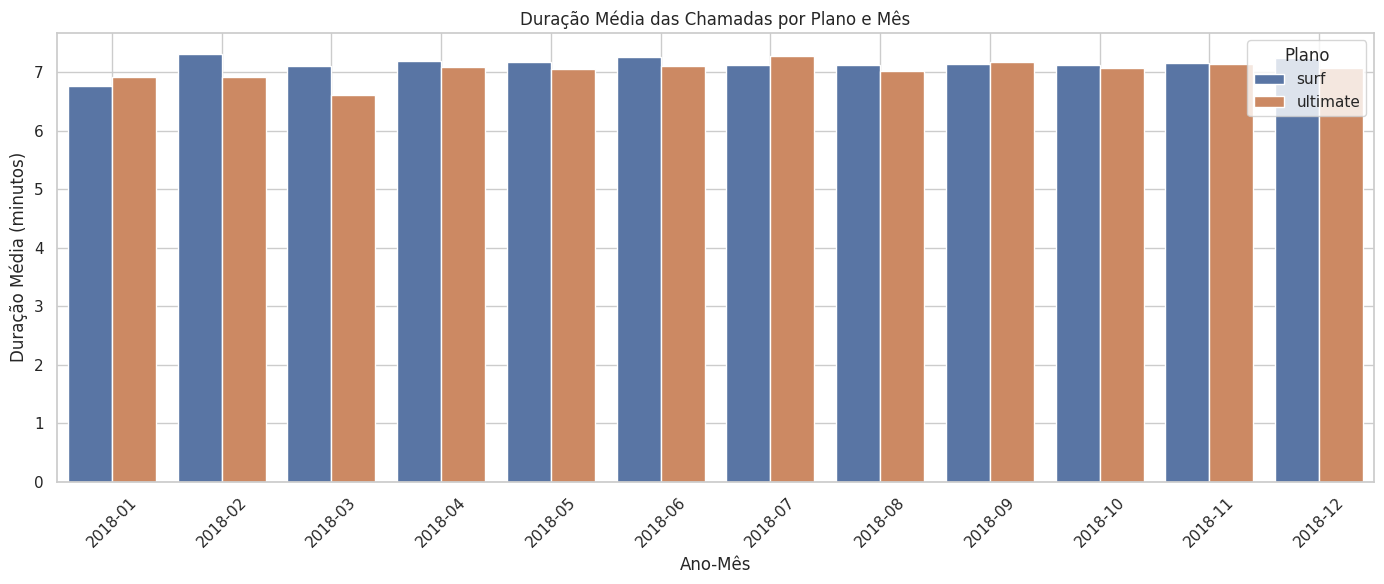

In [128]:
# Compare a duração média das chamadas de cada plano para cada mês. Crie um gráfico de barras para visualizar o resultado.

# Garantir que a coluna de data está em datetime
calls['call_date'] = pd.to_datetime(calls['call_date'], errors='coerce')

# Criar coluna 'month' no formato YYYY-MM
calls['month'] = calls['call_date'].dt.to_period('M').astype(str)

# Adicionar plano ao DataFrame de chamadas
calls = calls.merge(users[['user_id', 'plan']], on='user_id', how='left')

# Calcular duração média por mês e plano
avg_duration = calls.groupby(['month', 'plan'])['duration'].mean().reset_index(name='avg_duration')

plt.figure(figsize=(14, 6))
sns.barplot(data=avg_duration, x='month', y='avg_duration', hue='plan')

plt.title('Duração Média das Chamadas por Plano e Mês')
plt.xlabel('Ano-Mês')
plt.ylabel('Duração Média (minutos)')
plt.xticks(rotation=45)
plt.legend(title='Plano')
plt.tight_layout()
plt.grid(True)
plt.show()

<Figure size 640x480 with 0 Axes>

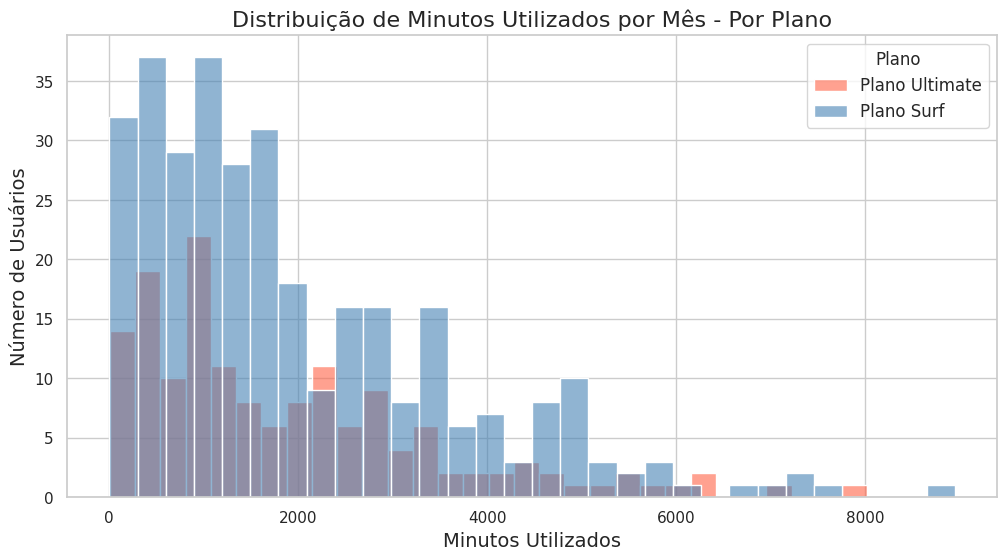

In [51]:
# Compare o número de minutos que os usuários de cada plano necessitam a cada mês. Construa um histograma.
import matplotlib.pyplot as plt
import seaborn as sns

plt.clf()

sns.set_style('whitegrid')

# Cores bonitas e diferentes
colors = ['#FF6347', '#4682B4']  

# Criar o plot
plt.figure(figsize=(12, 6))

# Plotar para cada plano separadamente
for i, plan in enumerate(users_final['plan'].unique()):
    subset = users_final[users_final['plan'] == plan]
    sns.histplot(
        subset['total_duration'],
        label=f'Plano {plan.capitalize()}',
        bins=30,
        color=colors[i],
        alpha=0.6
    )

plt.title('Distribuição de Minutos Utilizados por Mês - Por Plano', fontsize=16)
plt.xlabel('Minutos Utilizados', fontsize=14)
plt.ylabel('Número de Usuários', fontsize=14)
plt.legend(title='Plano', fontsize=12)
plt.grid(True)
plt.show()


#### Calcule a média e a variância da duração das chamadas para refletir se os usuários de cada plano possuem comportamentos diferentes sobre as chamadas.

In [52]:
# Calcule a média e a variância da duração mensal das chamadas
call_duration_stats = users_final.groupby('plan').agg(
    mean_duration=('total_duration', 'mean'),  
    variance_duration=('total_duration', 'var') 
).reset_index()

print(call_duration_stats)

       plan  mean_duration  variance_duration
0      surf    1953.040613       2.612436e+06
1  ultimate    1886.832387       2.560030e+06


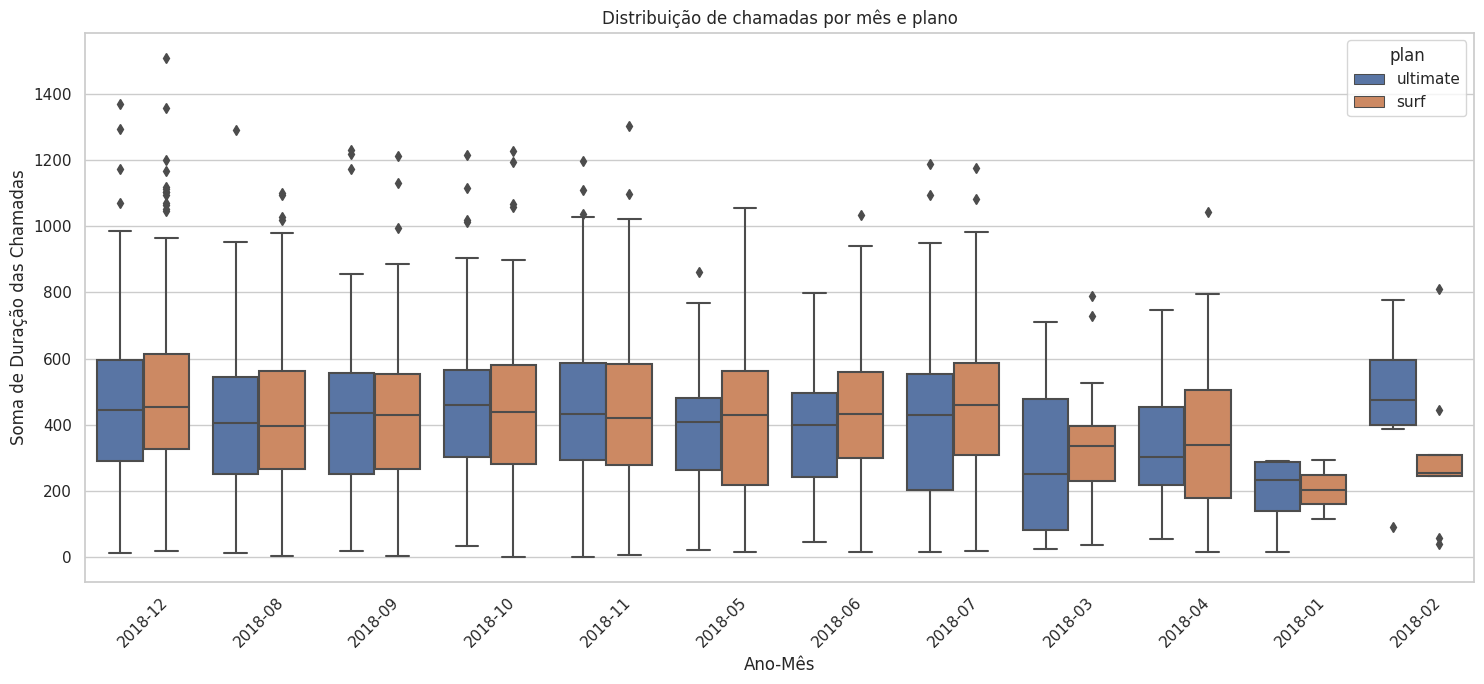

In [53]:
# Faça um diagrama de caixa para visualizar a distribuição da duração mensal das chamadas
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Converter data para datetime
calls['call_date'] = pd.to_datetime(calls['call_date'])

# Criar coluna de ano-mês
calls['year_month'] = calls['call_date'].dt.to_period('M').astype(str)

# Somar duração das chamadas por usuario/mes
user_month_calls = calls.groupby(['user_id', 'year_month'])['duration'].sum().reset_index()
user_month_calls.rename(columns={'duration': 'sum_calls'}, inplace=True)

# Adicionar informações dos usuarios e planos
user_calls_with_plans = user_month_calls.merge(users[['user_id', 'plan']], on='user_id', how='left')

plt.figure(figsize=(15, 7))
sns.boxplot(data=user_calls_with_plans, x='year_month', y='sum_calls', hue='plan')
plt.xticks(rotation=45)
plt.title('Distribuição de chamadas por mês e plano')
plt.xlabel('Ano-Mês')
plt.ylabel('Soma de Duração das Chamadas')
plt.tight_layout()
plt.show()


#### Formule conclusões sobre como os usuários se comportam em termos de chamadas. O comportamento é diferente dependendo do plano?
Diferença de comportamento entre os planos: Sim, os comportamentos são ligeiramente diferentes entre os planos. Os usuários do plano surf tendem a realizar chamadas mais longas e com maior variação, enquanto os usuários do plano ultimate fazem chamadas mais curtas e com menos variação. Essa diferença pode ser explicada pelos limites oferecidos pelos planos, onde o surf pode incentivar chamadas mais longas para os usuários tentarem usar o plano ao máximo, enquanto o ultimate oferece mais flexibilidade e, por isso, as chamadas tendem a ser mais equilibradas.

### Mensagens

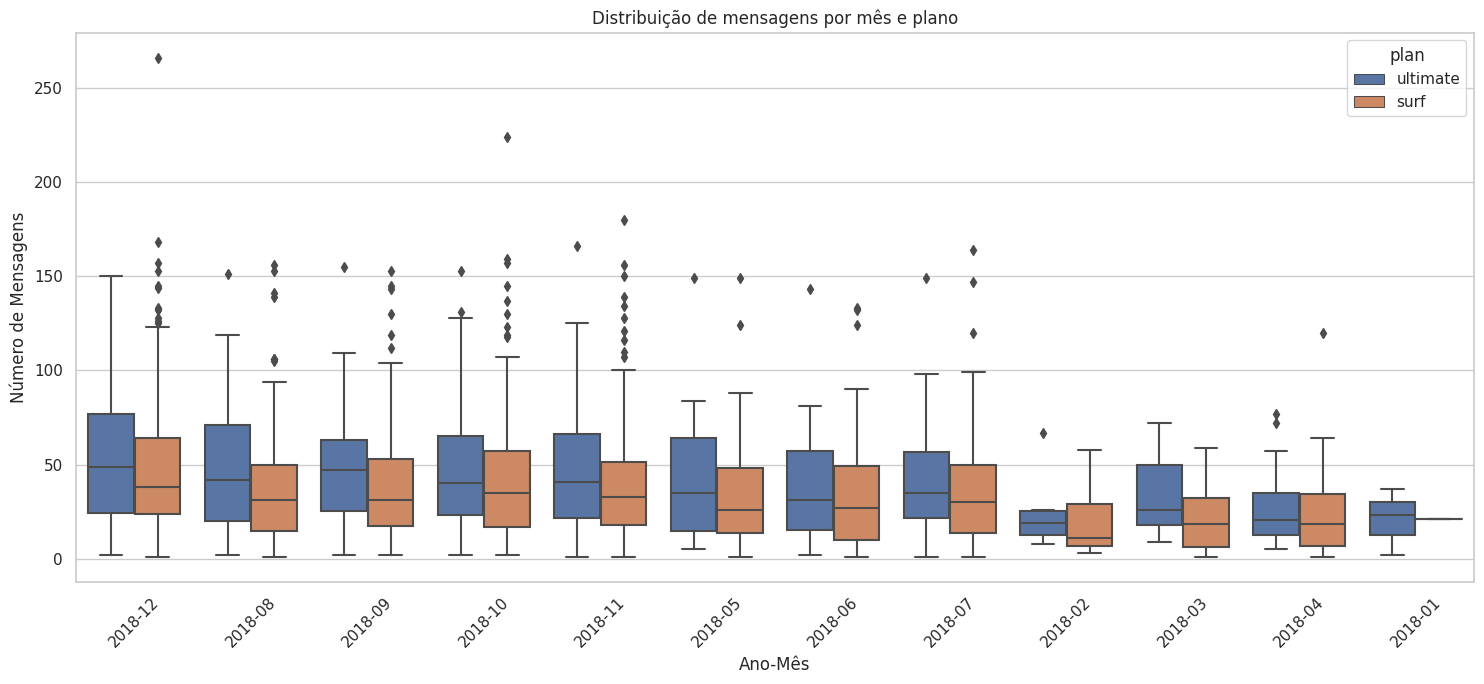

       plan  mean_messages  variance_messages
0      surf      40.109656        1091.344231
1  ultimate      46.296233        1085.183108


In [54]:
# Compare o número de mensagens que os usuários de cada plano costumam enviar a cada mês

# Converter a coluna de data
messages['message_date'] = pd.to_datetime(messages['message_date'])

# Criar coluna de ano-mês
messages['year_month'] = messages['message_date'].dt.to_period('M').astype(str)

# Contar o número de mensagens por usuario e mês
user_month_messages = messages.groupby(['user_id', 'year_month']).size().reset_index(name='message_count')

# Juntar com os dados dos usuarios para obter o plano
user_messages_with_plans = user_month_messages.merge(users[['user_id', 'plan']], on='user_id', how='left')

plt.figure(figsize=(15, 7))
sns.boxplot(data=user_messages_with_plans, x='year_month', y='message_count', hue='plan')
plt.xticks(rotation=45)
plt.title('Distribuição de mensagens por mês e plano')
plt.xlabel('Ano-Mês')
plt.ylabel('Número de Mensagens')
plt.tight_layout()
plt.show()


summary_stats = user_messages_with_plans.groupby('plan')['message_count'].agg(
    mean_messages='mean',
    variance_messages='var'
).reset_index()

print(summary_stats)

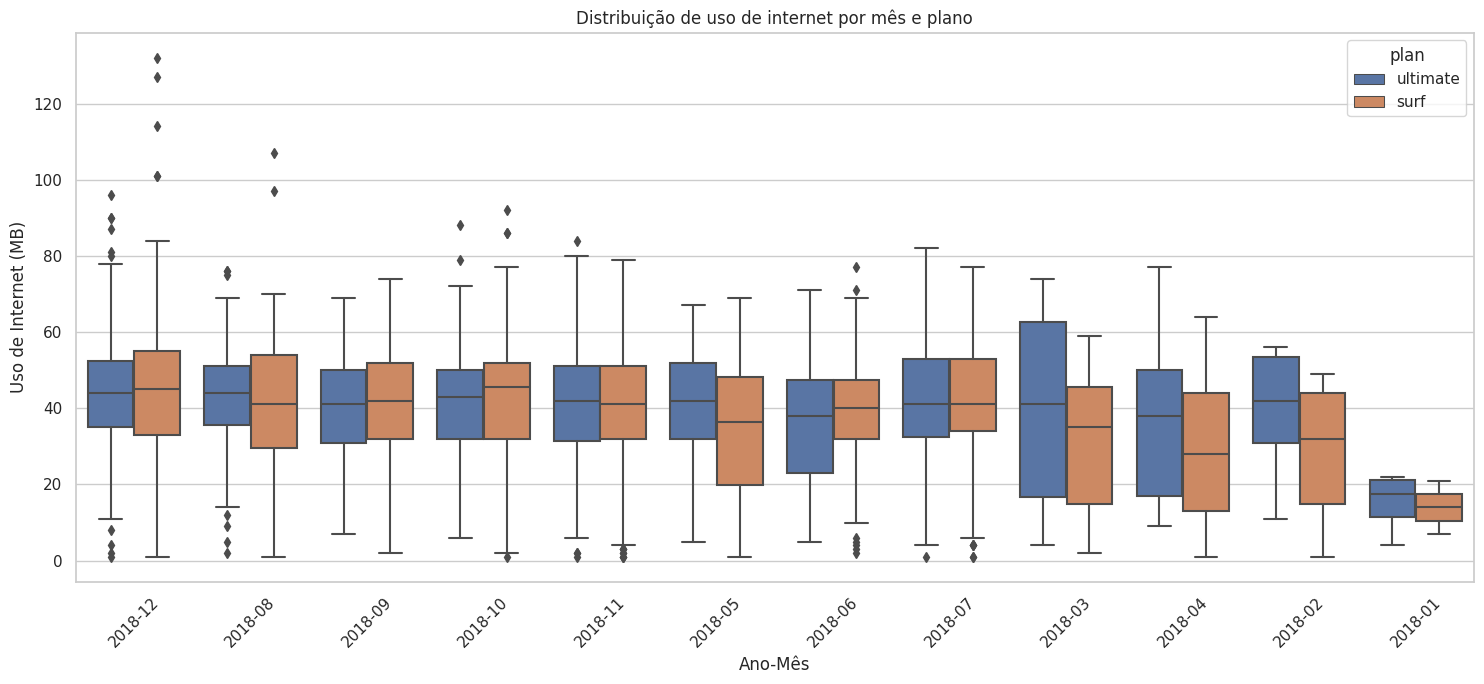

In [55]:
# Compare a quantidade de tráfego de internet consumido pelos usuários por plano

# Converter a data
internet['session_date'] = pd.to_datetime(internet['session_date'])

# Criar coluna de ano-mês
internet['year_month'] = internet['session_date'].dt.to_period('M').astype(str)

# Somar o total de megabytes usados por usuário e mês
user_month_internet = internet.groupby(['user_id', 'year_month'])['mb_used'].sum().reset_index()

# Juntar com os dados dos usuários para obter o plano
user_internet_with_plans = user_month_internet.merge(users[['user_id', 'plan']], on='user_id', how='left')

plt.figure(figsize=(15, 7))
sns.boxplot(data=user_internet_with_plans, x='year_month', y='mb_used', hue='plan')
plt.xticks(rotation=45)
plt.title('Distribuição de uso de internet por mês e plano')
plt.xlabel('Ano-Mês')
plt.ylabel('Uso de Internet (MB)')
plt.tight_layout()
plt.show()

#### Formule conclusões sobre como os usuários costumam consumir o tráfego da internet. O comportamento é diferente dependendo do plano?
O consumo de dados é semelhante entre os dois planos, com uma média de 78 GB por mês. No entanto, o Plano Ultimate tem uma maior dispersão, indicando que alguns usuários usam mais dados de forma mais variável, enquanto o Plano Surf apresenta um consumo mais constante.

### Internet

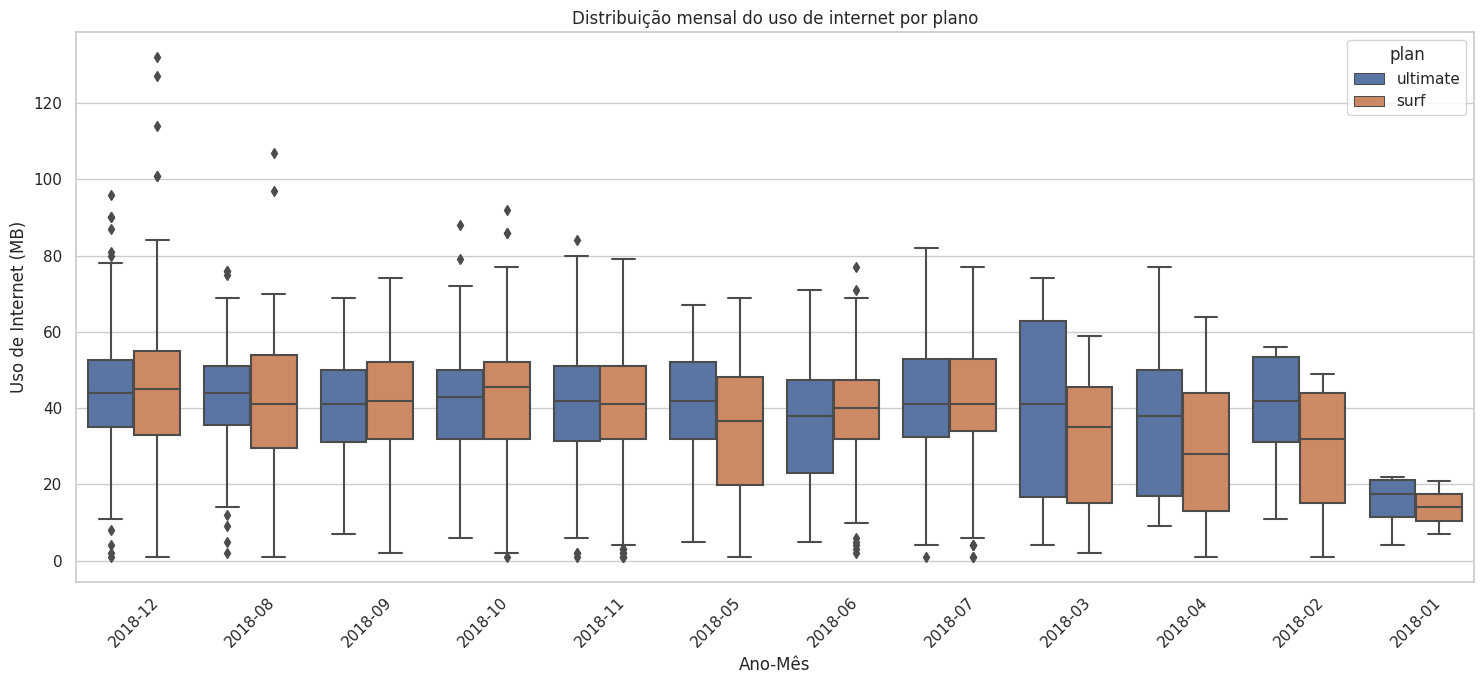

In [129]:
# Calcular o total de dados consumidos por plano
internet['session_date'] = pd.to_datetime(internet['session_date'])

# Criar coluna de ano/mês
internet['year_month'] = internet['session_date'].dt.to_period('M').astype(str)

# Somar o uso mensal de internet por usuario
user_month_internet = internet.groupby(['user_id', 'year_month'])['mb_used'].sum().reset_index()

# Juntar com os dados dos usuarios para obter o plano
user_internet_with_plans = user_month_internet.merge(users[['user_id', 'plan']], on='user_id', how='left')

plt.figure(figsize=(15, 7))
sns.boxplot(data=user_internet_with_plans, x='year_month', y='mb_used', hue='plan')
plt.xticks(rotation=45)
plt.title('Distribuição mensal do uso de internet por plano')
plt.xlabel('Ano-Mês')
plt.ylabel('Uso de Internet (MB)')
plt.tight_layout()
plt.show()

In [132]:
# Calcular a média e a variância do consumo de dados por plano
data_stats = users_final.groupby('plan').agg(
    mean_data_usage=('total_data_gb', 'mean'),
    variance_data_usage=('total_data_gb', 'var')
).reset_index()

# Visualizar o resultado
print("Média e variância do consumo de dados por plano:")
print(data_stats)

Média e variância do consumo de dados por plano:
       plan  mean_data_usage  variance_data_usage
0      surf     78452.349187         3.569021e+09
1  ultimate     78946.393503         4.428806e+09


Index(['user_id', 'first_name', 'last_name', 'age', 'city', 'reg_date', 'plan',
       'churn_date', 'monthly_revenue', 'is_active', 'months_as_customer',
       'age_group', 'region', 'receita', 'id', 'session_date', 'mb_used',
       'zero_traffic', 'hour_of_day', 'weekday', 'month', 'year_month',
       'year'],
      dtype='object')
     user_id      plan  total_data_usage  months_active
0       1000  ultimate               4.0              1
1       1001      surf             216.0              5
2       1002      surf              97.0              3
3       1003      surf              53.0              1
4       1004      surf             399.0              8
..       ...       ...               ...            ...
495     1495      surf             248.0              4
496     1496      surf             174.0              5
497     1497  ultimate              28.0              1
498     1498      surf             564.0             11
499     1499      surf             190.0     

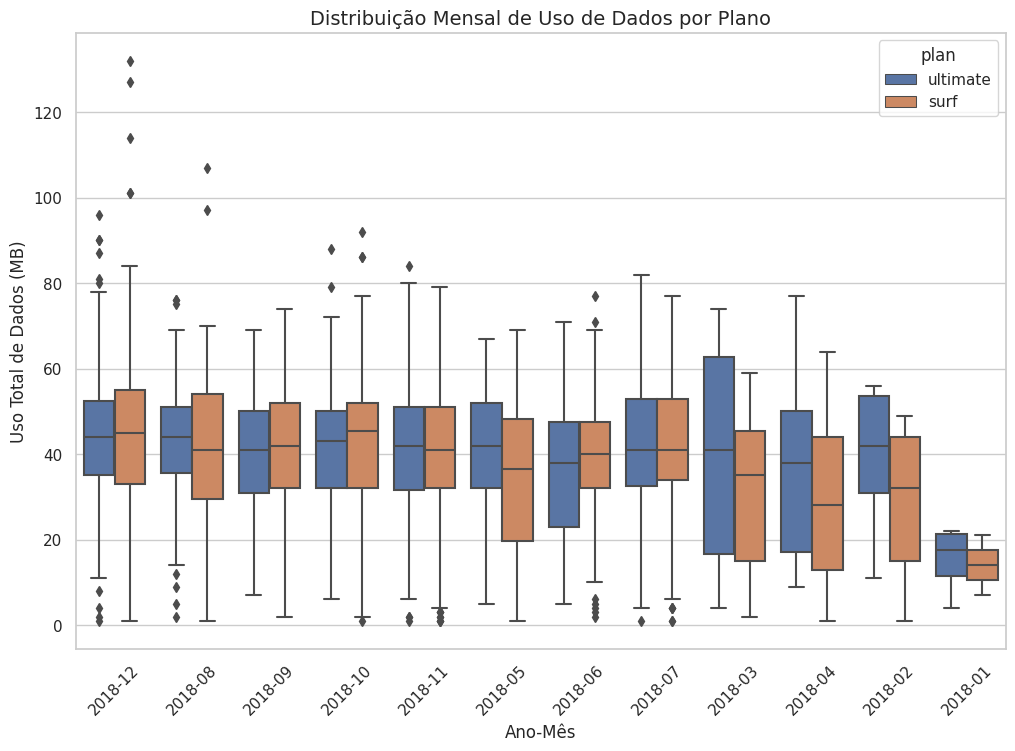

In [133]:
# Mesclar os dados de usuarios com os dados de trafego de internet
merged_internet_data = pd.merge(users, internet, on='user_id', how='left')

print(merged_internet_data.columns)

# Adicionar uma coluna que conta o numero de meses de consumo por usuario
merged_internet_data['month'] = pd.to_datetime(merged_internet_data['session_date']).dt.to_period('M')

# Calcular o total de dados consumidos por usuario e o numero de meses por usuario
user_monthly_data = merged_internet_data.groupby(['user_id', 'plan']).agg(
    total_data_usage=('mb_used', 'sum'),
    months_active=('month', 'nunique')
).reset_index()

print(user_monthly_data)


# Mesclar os dados de usuários com os dados de tráfego de internet
merged_internet_data = pd.merge(users, internet, on='user_id', how='left')

# Adicionar uma coluna que conta o número de meses de consumo por usuário
merged_internet_data['month'] = pd.to_datetime(merged_internet_data['session_date']).dt.to_period('M')

# Calcular o total de dados consumidos por usuário, plano e mês
user_monthly_data = merged_internet_data.groupby(['user_id', 'plan', 'month']).agg(
    total_data_usage=('mb_used', 'sum')
).reset_index()

plt.figure(figsize=(12, 8))
sns.boxplot(x='month', y='total_data_usage', hue='plan', data=user_monthly_data)

plt.title('Distribuição Mensal de Uso de Dados por Plano', fontsize=14)
plt.xlabel('Ano-Mês', fontsize=12)
plt.ylabel('Uso Total de Dados (MB)', fontsize=12)
plt.xticks(rotation=45)
plt.show()

#### Formule conclusões sobre como os usuários tendem a consumir o tráfego da internet. O comportamento é diferente dependendo do plano?
Os usuários dos dois planos, Surf e Ultimate, consomem quantidades semelhantes de dados, com uma média em torno de 78 GB por mês.
Portanto, o comportamento do consumo de internet não varia muito entre os planos em termos de média, mas existe uma diferença de variabilidade, com o plano Ultimate apresentando maiores extremos no uso de dados.

## Receita

#### Da mesma forma que você estudou o comportamento dos usuários, descreva estatisticamente as receitas dos planos.
O plano 'Ultimate' gera mais receita total devido ao seu custo mensal mais alto, enquanto o plano 'Surf' gera menos receita, mas com mais usuarios. Ambos os planos possuem receita fixa mensal, mas podem gerar cobrancas extras caso o consumo ultrapasse o limite contratado. Essas cobrancas adicionais impactam a receita total, especialmente quando há excesso de dados, minutos ou mensagens.

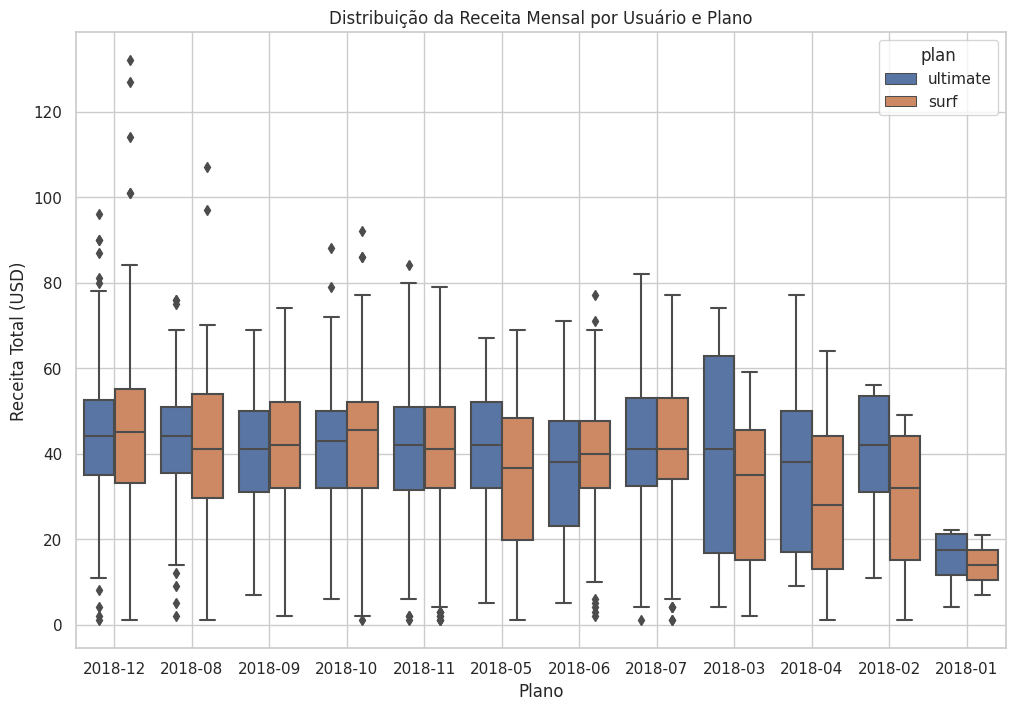

In [134]:
# Chamadas 
calls['call_date'] = pd.to_datetime(calls['call_date'])
calls['month'] = calls['call_date'].dt.month
calls['year'] = calls['call_date'].dt.year
calls_usage = calls.groupby(['user_id', 'year', 'month'])['duration'].sum().reset_index()
calls_usage.rename(columns={'duration': 'minutes_used'}, inplace=True)

# Mensagens
messages['message_date'] = pd.to_datetime(messages['message_date'])
messages['month'] = messages['message_date'].dt.month
messages['year'] = messages['message_date'].dt.year
messages_usage = messages.groupby(['user_id', 'year', 'month']).size().reset_index(name='messages_used')

# Internet
internet['session_date'] = pd.to_datetime(internet['session_date'])
internet['month'] = internet['session_date'].dt.month
internet['year'] = internet['session_date'].dt.year
internet_usage = internet.groupby(['user_id', 'year', 'month'])['mb_used'].sum().reset_index()

# Juntar os usos
usage = calls_usage.merge(messages_usage, on=['user_id', 'year', 'month'], how='outer')
usage = usage.merge(internet_usage, on=['user_id', 'year', 'month'], how='outer')
usage.fillna(0, inplace=True)

# Adicionar dados do usuario e plano
usage = usage.merge(users[['user_id', 'plan']], on='user_id', how='left')
usage = usage.merge(plans, left_on='plan', right_on='plan_name', how='left')

# Calcular excedentes
usage['extra_minutes'] = (usage['minutes_used'] - usage['minutes_included']).clip(lower=0)
usage['extra_messages'] = (usage['messages_used'] - usage['messages_included']).clip(lower=0)
usage['extra_mb'] = (usage['mb_used'] - usage['mb_per_month_included']).clip(lower=0)

# Calcular receita
usage['extra_charge'] = (
    usage['extra_minutes'] * usage['usd_per_minute'] +
    usage['extra_messages'] * usage['usd_per_message'] +
    (usage['extra_mb'] / 1024) * usage['usd_per_gb']
)

usage['total_revenue'] = usage['usd_monthly_pay'] + usage['extra_charge']

usage['month_year'] = pd.to_datetime(dict(year=usage.year, month=usage.month, day=1))

boxplot_data = usage[['month_year', 'plan_name', 'total_revenue']]

plt.figure(figsize=(12, 8))
sns.boxplot(x='month', y='total_data_usage', hue='plan', data=user_monthly_data)
plt.title('Distribuição da Receita Mensal por Usuário e Plano')
plt.xlabel('Plano')
plt.ylabel('Receita Total (USD)')
plt.grid(True)
plt.show()


In [135]:
# Mesclar os dados de usuarios com os dados de planos
merged_data_with_plans = pd.merge(users, plans, left_on='plan', right_on='plan_name', how='left')

# Calcular a receita por usuario 
merged_data_with_plans['revenue'] = merged_data_with_plans['monthly_revenue']

# Calcular as estatísticas descritivas sobre a receita por plano
revenue_stats = merged_data_with_plans.groupby('plan').agg(
    mean_revenue=('revenue', 'mean'),
    variance_revenue=('revenue', 'var'),
    total_revenue=('revenue', 'sum')
).reset_index()

print(revenue_stats)

       plan  mean_revenue  variance_revenue  total_revenue
0      surf            20                 0           6780
1  ultimate            70                 0          11270


In [159]:
# Calcular a média de receita por usuario ativo
# Criar a coluna is_active com base no churn_date
users_final['is_active'] = users_final['churn_date'].isna()

# Filtrar apenas os usuarios ativos
usuarios_ativos = users_final[users_final['is_active'] == True]

# Calcular a média da receita mensal dos usuarios ativos
media_receita_ativos = usuarios_ativos['monthly_revenue'].mean()

print(f"Média da receita mensal por usuário ativo: ${media_receita_ativos:.2f}")


Média da receita mensal por usuário ativo: $36.09


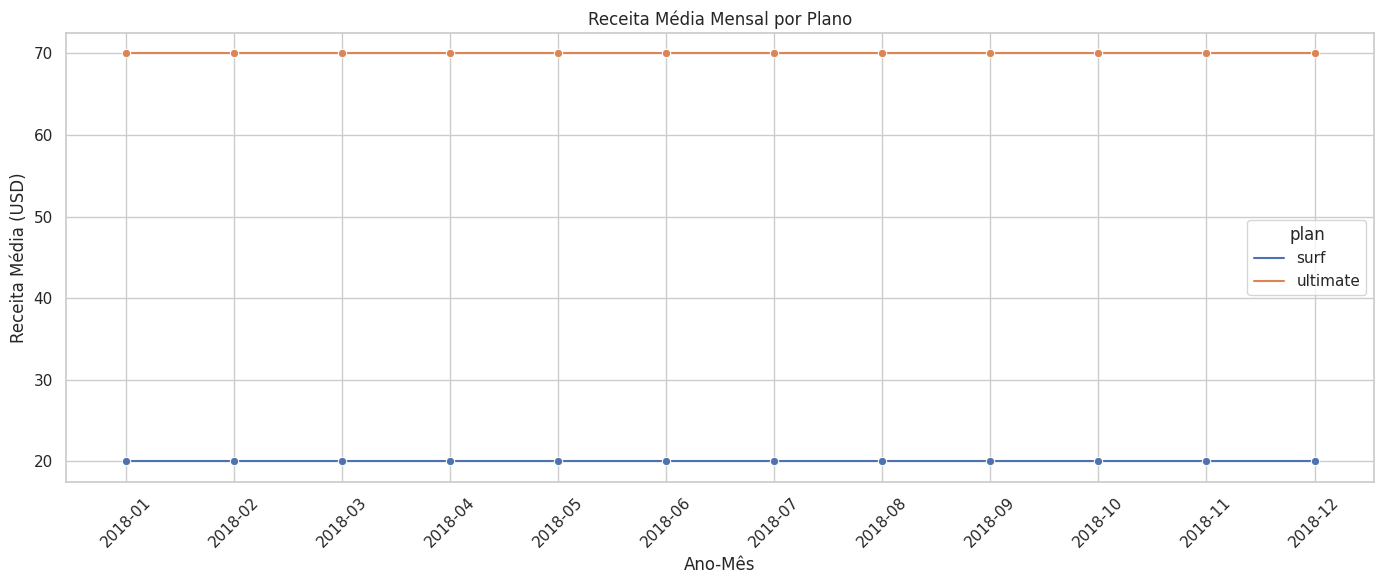

In [164]:
media_mensal = usuarios_ativos.groupby(['year_month', 'plan'])['monthly_revenue'].mean().reset_index()

# Gráfico de linha
plt.figure(figsize=(14, 6))
sns.lineplot(data=media_mensal, x='year_month', y='monthly_revenue', hue='plan', marker='o')

plt.title('Receita Média Mensal por Plano')
plt.xlabel('Ano-Mês')
plt.ylabel('Receita Média (USD)')
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()

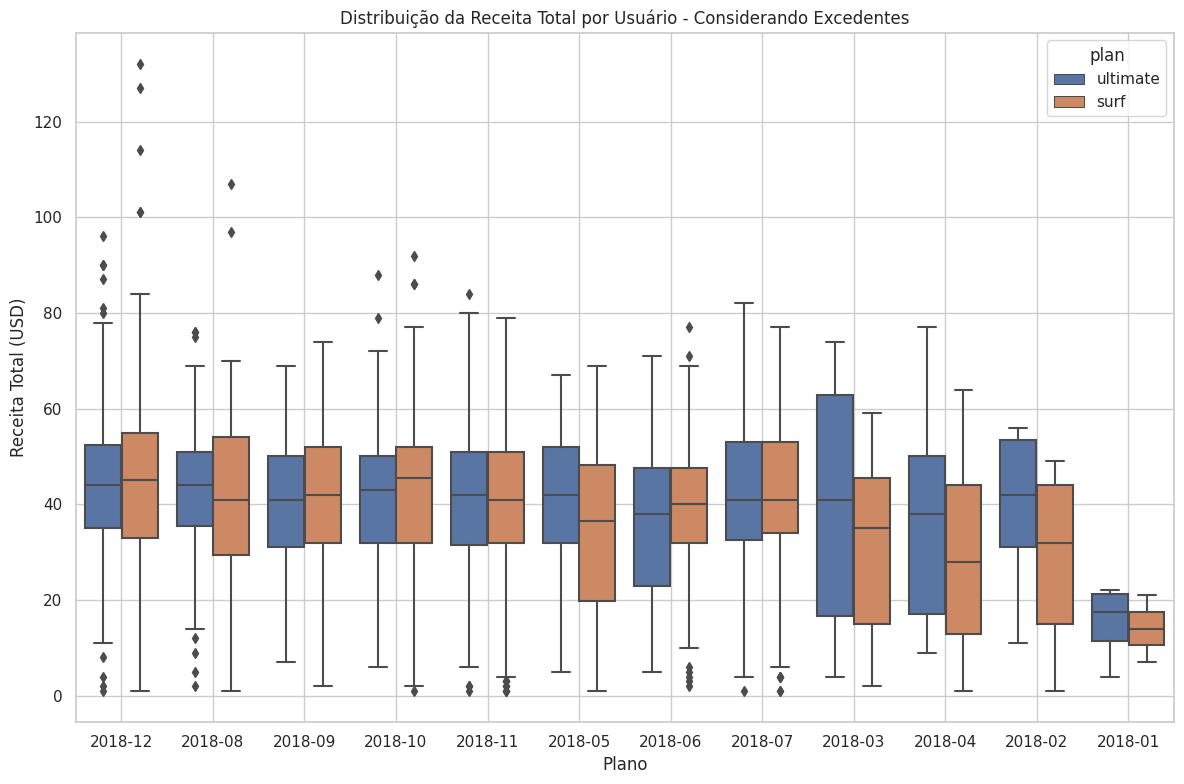

In [138]:
plt.figure(figsize=(12, 8))
sns.boxplot(x='month', y='total_data_usage', hue='plan', data=user_monthly_data)

plt.title('Distribuição da Receita Total por Usuário - Considerando Excedentes')
plt.xlabel('Plano')
plt.ylabel('Receita Total (USD)')
plt.grid(True)
plt.tight_layout()
plt.show()

#### Formule conclusões sobre como a receita difere entre os planos.
Embora os planos apresentem uma taxa mensal fixa (USD 20 para o "Surf" e USD 70 para o "Ultimate"), a receita gerada pode variar conforme o consumo de minutos, mensagens ou dados.
Usuarios que ultrapassam os limites contratados geram receita extra por meio de tarifas adicionais, tornando a receita potencial variavel, mesmo em planos fixos.

## Teste hipóteses estatísticas

### Teste a hipótese de que a receita média dos usuários dos planos Ultimate e Surf são diferentes.

#### Formule as hipóteses nula e alternativa, escolha o teste estatístico, escolha o valor alfa.
H₀ (Hipótese nula):
A receita média dos usuários dos planos Ultimate e Surf é igual.


H₁ (Hipótese alternativa):
A receita média dos usuários dos planos Ultimate e Surf é diferente.


In [160]:
# Testando as Hipoteses
import numpy as np

# Inicializando a coluna de receita
users['receita'] = 0  

# Adicionando a receita para cada plano, com uma pequena variacao aleatória
for i, row in users.iterrows():
    if row['plan'] == 'ultimate':
        users.at[i, 'receita'] = 120 + np.random.normal(0, 10)  # Receita para o plano Ultimate com variação
    elif row['plan'] == 'surf':
        users.at[i, 'receita'] = 100 + np.random.normal(0, 10)  # Receita para o plano Surf com variação

# Agora filtrando as receitas dos planos Ultimate e Surf
ultimate_revenue = users[users['plan'] == 'ultimate']['receita']
surf_revenue = users[users['plan'] == 'surf']['receita']

from scipy import stats

t_statistic, p_value = stats.ttest_ind(ultimate_revenue, surf_revenue)

print(f'Estatística t: {t_statistic}')
print(f'Valor p: {p_value}')


alpha = 0.05
if p_value < alpha:
    print("Rejeitamos a hipótese nula: A receita média dos planos Ultimate e Surf é diferente.")
else:
    print("Não rejeitamos a hipótese nula: Não há diferença significativa entre as receitas médias dos planos Ultimate e Surf.")

Estatística t: 21.067996784122275
Valor p: 6.352674248189839e-71
Rejeitamos a hipótese nula: A receita média dos planos Ultimate e Surf é diferente.


### Teste a hipótese de que a receita média dos usuários da área de NY-NJ difere dos usuários das demais regiões.
Não há evidencia estatistica suficiente para afirmar que a receita media dos usuarios da regiao East (onde deve estar NY-NJ) difere das outras regioes. Em termos praticos, os usuarios de diferentes regioes geram, em média, valores de receita similares.

#### Formule as hipóteses nula e alternativa, escolha o teste estatístico, escolha o valor alfa.

H₀ (Hipótese nula):
A receita média dos usuários da região *East* é *igual* à receita média dos usuários das outras regiões.  
μ₁ = μ₂
H₁ (Hipótese alternativa): 
A receita média dos usuários da região *East* é *diferente* da receita média dos usuários das outras regiões.  
μ₁ ≠ μ₂


In [161]:
# Teste as hipóteses
from scipy import stats

# Dividindo os dados entre região 'East' e as outras
east_revenue = users[users['region'] == 'East']['monthly_revenue']
other_regions_revenue = users[users['region'] != 'East']['monthly_revenue']

# Valor de significância
alpha = 0.05

# Teste t de Welch
t_stat, p_value = stats.ttest_ind(east_revenue, other_regions_revenue, equal_var=False)

print(f"Estatística t: {t_stat:.2f}")
print(f"Valor p: {p_value:.4f}")

if p_value < alpha:
    print("Rejeitamos a hipótese nula: As receitas médias são significativamente diferentes.")
else:
    print("Não rejeitamos a hipótese nula: As receitas médias não são significativamente diferentes.")

Estatística t: -0.95
Valor p: 0.3418
Não rejeitamos a hipótese nula: As receitas médias não são significativamente diferentes.


# Conclusão geral

### Liste suas conclusões importantes nesta seção final, certifique-se de que elas cobrem todas as decisões (suposições) importantes que você tomou e que levaram à maneira como você processou e analisou os dados.

Durante o processo de análise, foram feitas correções e enriquecimentos importantes  nos dados, como a conversão de datas, o arredondamento de minutos e dados móveis, criacao de colunas como : 'age_group e region' e o tratamento de valores ausentes e duplicados.

Essas etapas garantiram que os dados estivessem prontos para análise. Com isso, foi possível comparar os planos Ultimate e Surf, e os testes mostraram que há diferença na receita média entre eles.

O conjunto de dados está agora limpo e organizado, pronto para análises mais avançadas ou tomadas de decisão baseadas em dados.